Первые уровни энергии:

n         DVR                 Точное              Ошибка
1         4.9348022005        4.9348022005        1.066e-12
2         19.7392088022       19.7392088022       1.169e-12
3         44.4132198049       44.4132198049       1.108e-12
4         78.9568352087       78.9568352087       1.137e-12
5         123.3700550136      123.3700550136      1.023e-12
6         177.6528792196      177.6528792196      1.137e-12
7         241.8053078267      241.8053078267      6.537e-13
8         315.8273408349      315.8273408349      3.979e-13
9         399.7189782441      399.7189782441      5.116e-13
10        493.4802200545      493.4802200545      7.390e-13


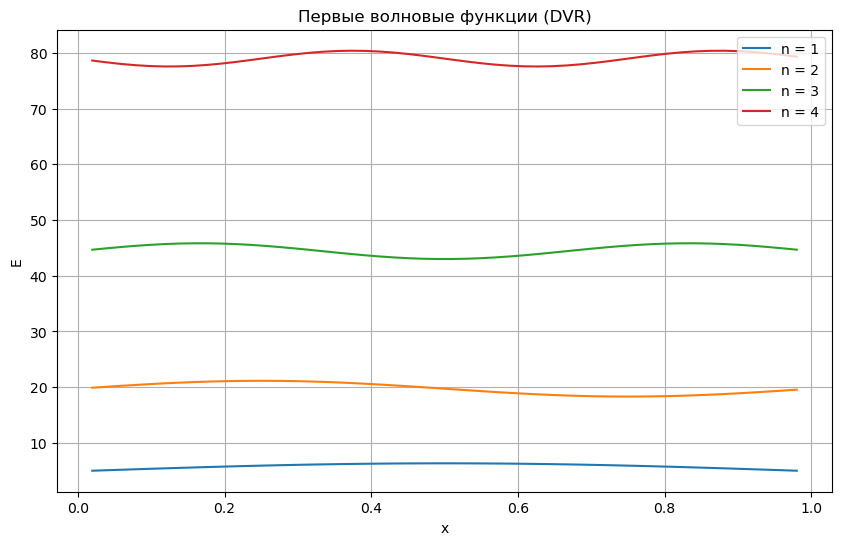


Сходимость энергии основного состояния

N         E1 (DVR)            E1 exact            Отн. ошибка
10        4.934802200545      4.934802200545      1.422e-14
20        4.934802200545      4.934802200545      8.999e-16
30        4.934802200545      4.934802200545      1.980e-14
40        4.934802200544      4.934802200545      5.813e-14
50        4.934802200544      4.934802200545      2.379e-13
60        4.934802200545      4.934802200545      8.369e-14
80        4.934802200544      4.934802200545      1.740e-13
100       4.934802200540      4.934802200545      9.480e-13


In [11]:

import numpy as np
import matplotlib.pyplot as plt
from scipy.linalg import eigh


# ПАРАМЕТРЫ ЗАДАЧИ

N = 50          
L = 1.0         
hbar = 1.0
m = 1.0



x = np.array([(j + 1) * L / (N + 1) for j in range(N)])

# шаг сетки
dx = L / (N + 1)



def V(x):
    return 0.0

V_diag = np.array([V(xj) for xj in x])



j = np.arange(1, N + 1)
n = np.arange(1, N + 1)

U = np.sqrt(2 / (N + 1)) * np.sin(
    np.pi * np.outer(j, n) / (N + 1)
)

T_diag = (hbar**2 / (2 * m)) * (
    (np.pi**2 * n**2) / (L**2)
)


T = U @ np.diag(T_diag) @ U.T


V_matrix = np.diag(V_diag)


H = T + V_matrix


energies, psi = eigh(H)


n_levels = 10

E_exact = np.array([
    (np.pi**2 * n**2) / (2 * L**2)
    for n in range(1, n_levels + 1)
])

print("Первые уровни энергии:\n")

print(f"{'n':<10}{'DVR':<20}{'Точное':<20}{'Ошибка'}")

for n in range(n_levels):

    err = abs(energies[n] - E_exact[n])

    print(f"{n+1:<10}"
          f"{energies[n]:<20.10f}"
          f"{E_exact[n]:<20.10f}"
          f"{err:.3e}")



for n in range(n_levels):
    norm = np.sqrt(np.trapezoid(np.abs(psi[:, n])**2, x))
    psi[:, n] /= norm


plt.figure(figsize=(10, 6))

for n in range(4):

    plt.plot(
        x,
        psi[:, n] + energies[n],
        label=f'n = {n+1}'
    )

plt.xlabel("x")
plt.ylabel("E")
plt.title("Первые волновые функции (DVR)")
plt.grid(True)
plt.legend()

plt.show()

# ------------------------------------------------------------
# ТАБЛИЦА СХОДИМОСТИ ЭНЕРГИИ ОСНОВНОГО СОСТОЯНИЯ
# ------------------------------------------------------------

def build_T(N, L, hbar=1.0, m=1.0):

    j = np.arange(1, N + 1)
    n = np.arange(1, N + 1)

    U = np.sqrt(2 / (N + 1)) * np.sin(
        np.pi * np.outer(j, n) / (N + 1)
    )

    T_diag = (hbar**2 / (2 * m)) * (
        (np.pi**2 * n**2) / (L**2)
    )

    return U @ np.diag(T_diag) @ U.T


# точное значение энергии основного состояния
E1_exact = (np.pi**2) / (2 * L**2)

# значения N
N_range = [10, 20, 30, 40, 50, 60, 80, 100]

print("\nСходимость энергии основного состояния\n")

print(f"{'N':<10}"
      f"{'E1 (DVR)':<20}"
      f"{'E1 exact':<20}"
      f"{'Отн. ошибка'}")

for Ni in N_range:

    # гамильтониан
    Ti = build_T(Ni, L, hbar, m)
    Hi = Ti

    # основное состояние
    E1_num = eigh(Hi, eigvals_only=True)[0]

    # относительная ошибка
    rel_error = abs(E1_num - E1_exact) / E1_exact

    print(f"{Ni:<10}"
          f"{E1_num:<20.12f}"
          f"{E1_exact:<20.12f}"
          f"{rel_error:.3e}")